Found 3896 images belonging to 3 classes.
Found 973 images belonging to 3 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 74s 506ms/step - accuracy: 0.3237 - loss: 1.5070 - val_accuracy: 0.3700 - val_loss: 1.1179
Epoch 2/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 48s 381ms/step - accuracy: 0.3575 - loss: 1.2106 - val_accuracy: 0.3453 - val_loss: 1.1457
Epoch 3/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 44s 356ms/step - accuracy: 0.3605 - loss: 1.1627 - val_accuracy: 0.3505 - val_loss: 1.1000
Epoch 4/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 81s 657ms/step - accuracy: 0.3606 - loss: 1.1417 - val_accuracy: 0.3597 - val_loss: 1.1008
Epoch 5/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 73s 568ms/step - accuracy: 0.3769 - loss: 1.1269 - val_accuracy: 0.3926 - val_loss: 1.0852
Epoch 6/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 62s 498ms/step - accuracy: 0.3707 - loss: 1.1123 - val_accuracy: 0.3864 - val_loss: 1.0847
Epoch 7/25
122/122 ━━━━━━━━━━━━━━━━━━━━ 64s 509ms/step - accuracy: 0.3847 - loss: 

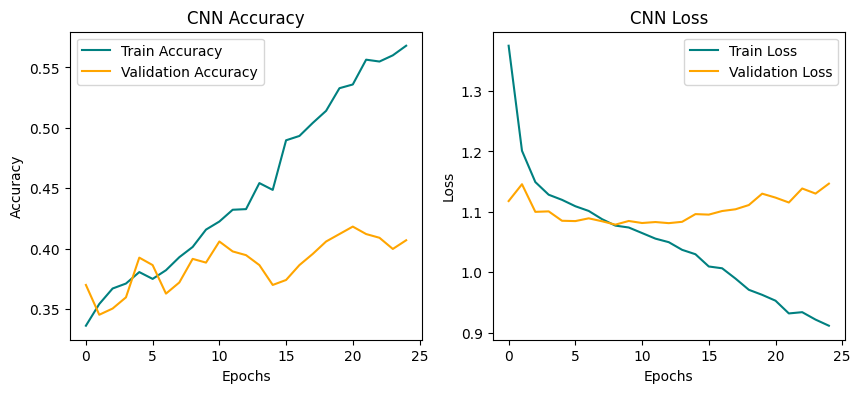

✅ Optimized Image Sentiment Model Trained & Saved Successfully!


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Dataset Path
dataset_path = "D:\\final year project\\Images"  # Update this with your dataset path

# Data Augmentation & Normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

# Load Training & Validation Data
train_data = datagen.flow_from_directory(
    dataset_path, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='training'
)
val_data = datagen.flow_from_directory(
    dataset_path, target_size=(128, 128), batch_size=32, class_mode='categorical', subset='validation'
)

# Load Pretrained MobileNetV2 Model
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(128, 128, 3))

# Fine-Tune More Layers
for layer in base_model.layers[:-30]:  # Previously -20, now -30
    layer.trainable = False

# Define CNN Model
cnn_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

# Compile Model with Learning Rate Scheduler
initial_learning_rate = 0.0005
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps=100, decay_rate=0.9, staircase=True
)

cnn_model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = cnn_model.fit(
    train_data, epochs=25, validation_data=val_data
)

# Save Model
cnn_model.save("optimized_sentiment_cnn_model.keras")

# Training Visualization
plt.figure(figsize=(10, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='teal')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='teal')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('CNN Loss')

plt.show()

print("✅ Optimized Image Sentiment Model Trained & Saved Successfully!")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kalya/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\kalya/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!



🔹 Random Forest Accuracy: 79.34%
              precision    recall  f1-score   support

          -1       0.77      0.71      0.74      1655
           0       0.83      0.91      0.87      1656
           1       0.77      0.76      0.77      1656

    accuracy                           0.79      4967
   macro avg       0.79      0.79      0.79      4967
weighted avg       0.79      0.79      0.79      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


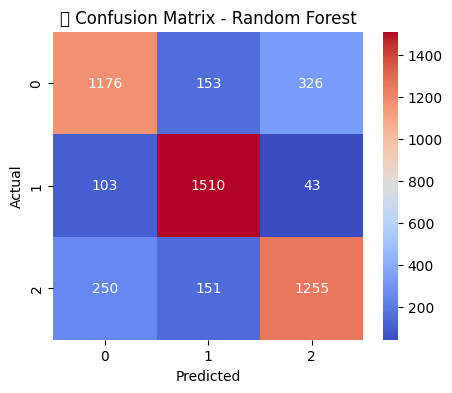


🔹 Naïve Bayes Accuracy: 69.20%
              precision    recall  f1-score   support

          -1       0.63      0.75      0.69      1655
           0       0.78      0.58      0.66      1656
           1       0.70      0.75      0.72      1656

    accuracy                           0.69      4967
   macro avg       0.70      0.69      0.69      4967
weighted avg       0.70      0.69      0.69      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


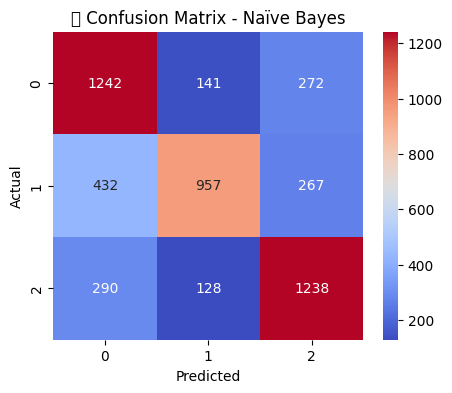


🔹 SVM Accuracy: 83.73%
              precision    recall  f1-score   support

          -1       0.83      0.78      0.80      1655
           0       0.84      0.95      0.89      1656
           1       0.85      0.78      0.81      1656

    accuracy                           0.84      4967
   macro avg       0.84      0.84      0.84      4967
weighted avg       0.84      0.84      0.84      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


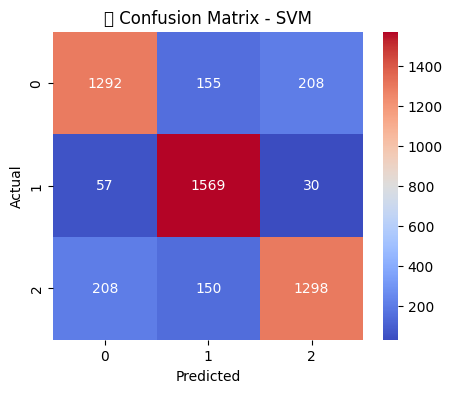


🔹 Logistic Regression Accuracy: 82.59%
              precision    recall  f1-score   support

          -1       0.83      0.76      0.79      1655
           0       0.82      0.93      0.87      1656
           1       0.84      0.78      0.81      1656

    accuracy                           0.83      4967
   macro avg       0.83      0.83      0.82      4967
weighted avg       0.83      0.83      0.82      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


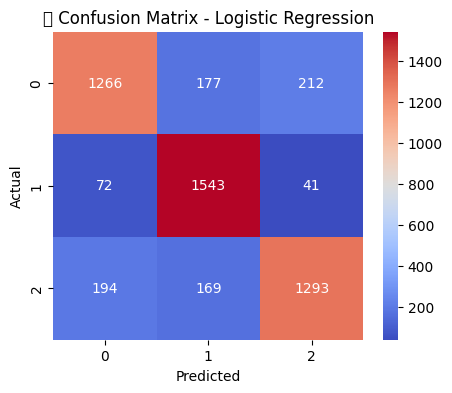


🔹 KNN Accuracy: 39.22%
              precision    recall  f1-score   support

          -1       0.73      0.11      0.18      1655
           0       0.35      0.96      0.52      1656
           1       0.87      0.11      0.19      1656

    accuracy                           0.39      4967
   macro avg       0.65      0.39      0.30      4967
weighted avg       0.65      0.39      0.30      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


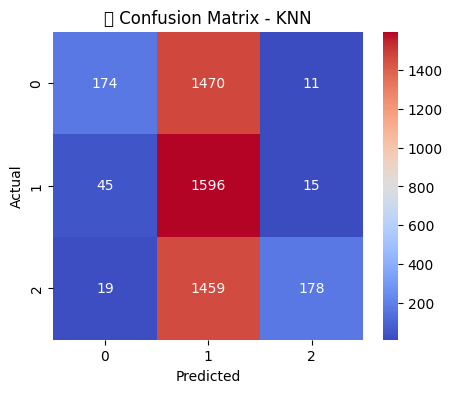

✅ Optimized Text Sentiment Models Trained & Saved Successfully!


In [4]:
import numpy as np
import pandas as pd
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Load dataset
df = pd.read_csv("D:\\final year project\\Reddit_Data.csv")

# Rename column for consistency
df.rename(columns={'clean_comment': 'comment'}, inplace=True)

# Text Preprocessing
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove special characters
    text = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words]
    return " ".join(text)

df['clean_comment'] = df['comment'].astype(str).apply(clean_text)
df.dropna(subset=['clean_comment'], inplace=True)

# Handle Class Imbalance
X_text = df['clean_comment']
y_text = df['category']
undersample = RandomUnderSampler(random_state=42)
X_text_resampled, y_text_resampled = undersample.fit_resample(X_text.values.reshape(-1, 1), y_text)
X_text_resampled = X_text_resampled.flatten()

# TF-IDF Vectorization (Fast Processing)
vectorizer = TfidfVectorizer(max_features=3000)  # Increased features for better representation
X_text_vec = vectorizer.fit_transform(X_text_resampled).toarray()

# Train-Test Split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text_vec, y_text_resampled, test_size=0.2, random_state=42, stratify=y_text_resampled
)

# Machine Learning Models (Optimized)
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "Naïve Bayes": MultinomialNB(),
    "SVM": SVC(kernel='linear', probability=True),
    "Logistic Regression": LogisticRegression(max_iter=200, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train_text, y_train_text)
    joblib.dump(model, f"{name.replace(' ', '_').lower()}_model.pkl")
    y_pred = model.predict(X_test_text)

    print(f"\n🔹 {name} Accuracy: {np.mean(y_pred == y_test_text) * 100:.2f}%")
    print(classification_report(y_test_text, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test_text, y_pred), annot=True, cmap="coolwarm", fmt="d")
    plt.title(f"🔹 Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Save Vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("✅ Optimized Text Sentiment Models Trained & Saved Successfully!")
